# **Retail Sales Analysis and Prediction**
# 1. Import Libraries
# 2. Load Dataset
# 3. Data Cleaning
# 4. Exploratory Data Analysis
# 5. Machine Learning Model
# 6. Results
# 7. Conclusion

**Retail Sales Analysis and Prediction
Objective bold text**

The objective of this project is to analyze retail sales data, extract business insights, and build a machine learning model to predict total sales.

In [42]:
!pip install pandas numpy matplotlib seaborn scikit-learn

**1. Importing Required Libraries**

In this section, we import all necessary Python libraries for data analysis, visualization, and machine learning.

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
%matplotlib inline


**2. Loading the Dataset**

The dataset is loaded using pandas. It contains retail sales transactions including product details, quantity, price, and date of purchase.

In [44]:
df = pd.read_csv("RetailSales.csv")
df.head()

,Invoice_ID,Customer_ID,Product_Name,Category,Quantity,Price,Total_Sales,Date
0,I-1,35,Tablet,Electronics,7,360.68,2524.76,18-03-2024
1,I-2,34,Rice,Groceries,6,128.33,769.98,26-02-2024
2,I-3,97,Yoga Mat,Sports,2,515.10,1030.20,08-12-2024
3,I-4,2,Eggs,Groceries,1,733.72,733.72,28-02-2024
4,I-5,100,Dumbbells,Sports,2,815.41,1630.82,25-02-2024


The dataset preview shows the structure of the data including product categories, pricing, and sales information.

**3. Data Cleaning and Preparation**

Before analysis, we ensure that:
1.There are no missing values
2.Total_Sales is correctly calculated
3.Date column is converted to datetime format
4.Month column is extracted for time-based analysis









In [45]:
df.shape

(1000, 8)

In [46]:
df.columns

Index(['Invoice_ID', 'Customer_ID', 'Product_Name', 'Category', 'Quantity',
       'Price', 'Total_Sales', 'Date'],
      dtype='object')

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Invoice_ID    1000 non-null   object 
 1   Customer_ID   1000 non-null   int64  
 2   Product_Name  1000 non-null   object 
 3   Category      1000 non-null   object 
 4   Quantity      1000 non-null   int64  
 5   Price         1000 non-null   float64
 6   Total_Sales   1000 non-null   float64
 7   Date          1000 non-null   object 
dtypes: float64(2), int64(2), object(4)
memory usage: 62.6+ KB


In [48]:
df.isnull().sum()

,0
Invoice_ID,0
Customer_ID,0
Product_Name,0
Category,0
Quantity,0
Price,0
Total_Sales,0
Date,0


In [49]:
df['Date'] = pd.to_datetime(df['Date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Invoice_ID    1000 non-null   object        
 1   Customer_ID   1000 non-null   int64         
 2   Product_Name  1000 non-null   object        
 3   Category      1000 non-null   object        
 4   Quantity      1000 non-null   int64         
 5   Price         1000 non-null   float64       
 6   Total_Sales   1000 non-null   float64       
 7   Date          1000 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(2), object(3)
memory usage: 62.6+ KB


/tmp/ipython-input-2345423161.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


**4. Exploratory Data Analysis (EDA)
Category-wise Sales Analysis**

We analyze total revenue generated by each product category to identify the most profitable segment.

In [50]:
category_sales = df.groupby('Category')['Total_Sales'].sum()
category_sales

,Total_Sales
Category,
Clothing,600020.64
Electronics,554400.20
Groceries,584065.33
Home Decor,476812.82
Sports,538967.61


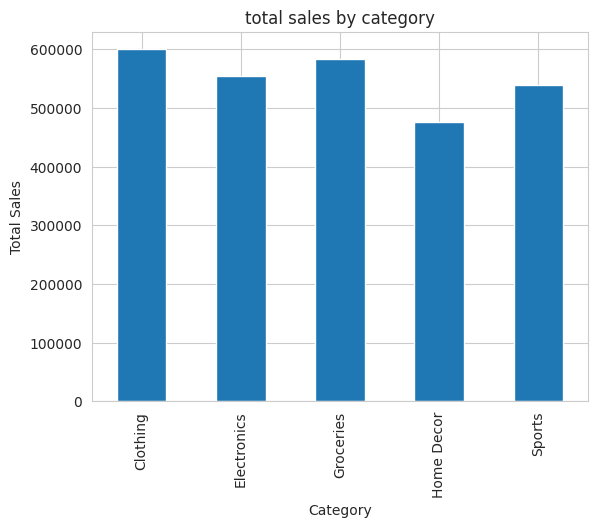

In [51]:
category_sales.plot(kind='bar')
plt.title("total sales by category")
plt.ylabel("Total Sales")
plt.show()

**5.Product-wise Sales Analysis**

This analysis identifies the best-selling product based on total sales value.

In [52]:
top_products = df.groupby('Product_Name')['Total_Sales'].sum().sort_values(ascending=False).head(5)
top_products

,Total_Sales
Product_Name,
Headphones,162273.02
Jeans,144115.71
Eggs,140053.72
Rice,137759.99
Wall Art,129214.02


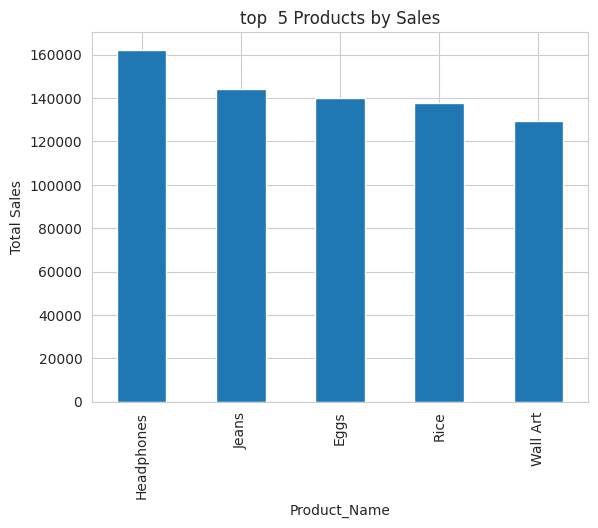

In [53]:
top_products.plot(kind='bar')
plt.title("top  5 Products by Sales")
plt.ylabel("Total Sales")
plt.show()

**6.Monthly Sales Trend**

We analyze sales distribution across months to detect seasonal patterns and trends.

In [54]:
df['Month'] = df['Date'].dt.month
df.head()

,Invoice_ID,Customer_ID,Product_Name,Category,Quantity,Price,Total_Sales,Date,Month
0,I-1,35,Tablet,Electronics,7,360.68,2524.76,2024-03-18,3
1,I-2,34,Rice,Groceries,6,128.33,769.98,2024-02-26,2
2,I-3,97,Yoga Mat,Sports,2,515.10,1030.20,2024-12-08,12
3,I-4,2,Eggs,Groceries,1,733.72,733.72,2024-02-28,2
4,I-5,100,Dumbbells,Sports,2,815.41,1630.82,2024-02-25,2


In [55]:
Monthly_Sales = df.groupby('Month')['Total_Sales'].sum()
Monthly_Sales

,Total_Sales
Month,
1,266885.17
2,208006.03
3,211919.18
4,222534.37
5,198478.75
6,159229.36
7,225786.74
8,219086.79
9,282116.85


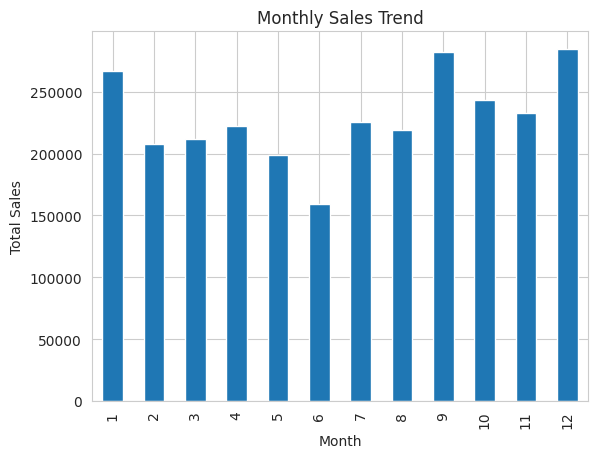

In [56]:
Monthly_Sales.plot(kind='bar')
plt.title("Monthly Sales Trend")
plt.ylabel("Total Sales")
plt.xlabel("Month")
plt.show()

**7. Machine Learning Model**

We build a Linear Regression model to predict Total_Sales using:

Quantity

Price

Month

The dataset is split into training (80%) and testing (20%) sets.

In [57]:
X = df[['Quantity', 'Price', 'Month']]
y = df['Total_Sales']
X.head()

,Quantity,Price,Month
0,7,360.68,3
1,6,128.33,2
2,2,515.10,12
3,1,733.72,2
4,2,815.41,2


In [58]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [59]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [60]:
y_pred = model.predict(X_test)

**8. Model Evaluation**

We evaluate the model using the R² score to measure how well the model explains the variation in total sales.

In [61]:
from sklearn.metrics import r2_score

r2_score(y_test, y_pred)

0.8697905629169367

**9. Conclusion**

From the analysis, we conclude that:

Clothing is the highest revenue-generating category.

Headphones are the top-selling product.

Sales increase towards the end of the year, with December showing the highest sales.

Linear Regression achieved an R² score of 0.8697, indicating strong predictive performance.

This project demonstrates the complete data analysis workflow from data cleaning to machine learning modeling.